# SMA Kesişim Stratejisi ve Buy & Hold Karşılaştırması

**Amaç:** Dört ETF'in (SPY, QQQ, GLD, TUR) son 10 yıllık günlük fiyat verisini kodla indirmek, temizlemek ve basit bir hareketli ortalama (SMA) stratejisini "al ve tut" (Buy & Hold) yaklaşımıyla karşılaştırmak.

**Adımlar:** veri çekme → temizleme → dönemsel getiriler → strateji → backtest → sonuçlar

**Bu notebook nasıl okunur?**
Projenin kodu `scripts/` klasöründeki dört dosyada durur: `config.py`, `fetch_data.py`, `clean_data.py`, `backtest.py`. Notebook bu dosyalardaki fonksiyonları import eder. Her bölümde önce ilgili fonksiyonun **kodu** (yorum satırlarıyla birlikte) gösterilir, ardından fonksiyon çalıştırılır ve sonucu incelenir.

Fonksiyonların tek bir kopyası vardır: burada gösterilen fonksiyonlar, `python run_all.py` komutuyla çalışanların aynısıdır.

## 0. Hazırlık

Kütüphaneleri ve `scripts/` klasöründeki dosyaları yüklüyoruz. `show_code`, bir fonksiyonun kaynak kodunu ekrana basan küçük bir yardımcıdır.

In [1]:
import inspect
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

# scripts/ klasörünü Python yoluna ekle (notebook bir alt klasörde duruyor)
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import config
import fetch_data
import clean_data
import backtest


def show_code(obj):
    # Bir fonksiyonun (ya da dosyanın) kaynak kodunu kod bloğu olarak gösterir
    return Markdown(f"```python\n{inspect.getsource(obj)}\n```")

In [2]:
# Grafik ayarları: sade görünüm, silik ızgara çizgileri
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
})

# Grafiklerde kullanılan renkler
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"  # çizgiler
GREEN, RED = "#0ca30c", "#d03b3b"                     # pozitif / negatif

# Tablolarda sayıları iki ondalıkla göster
pd.options.display.float_format = "{:,.2f}".format

## 1. Ayarlar

Semboller, dönem ve strateji parametreleri tek bir dosyada (`scripts/config.py`) durur. Bir değeri değiştirmek için sadece bu dosyayı düzenlemek yeterlidir.

In [3]:
show_code(config)

```python
"""Projenin tüm ayarları tek yerde. Scriptler ve notebook buradan okur."""
from pathlib import Path

# İncelenecek semboller (ETF) ve kısa açıklamaları
SYMBOLS = {
    "SPY": "S&P 500",
    "QQQ": "Nasdaq 100",
    "GLD": "Altın",
    "TUR": "iShares MSCI Turkey ETF",
}

YEARS = 10                 # kaç yıllık veri çekilecek

# Strateji parametreleri
SMA_SHORT = 50             # kısa hareketli ortalama (gün)
SMA_LONG = 200             # uzun hareketli ortalama (gün)
COMMISSION = 0.001         # her işlemde %0.1 komisyon
INITIAL_CAPITAL = 10_000   # başlangıç sermayesi ($)
TRADING_DAYS = 252         # bir yıldaki işlem günü sayısı (yıllıklandırma için)

# Veri çekme ayarları
REQUEST_TIMEOUT = 30       # bir isteğin en fazla bekleme süresi (saniye)
MAX_RETRIES = 3            # bir istek en fazla kaç kez denenir
SLEEP_SECONDS = 2          # istekler arasındaki bekleme (saniye)

# Klasörler
ROOT = Path(__file__).resolve().parent.parent
RAW_DIR = ROOT / "data" / "raw"          # indirilen ham veri
CLEAN_DIR = ROOT / "data" / "clean"      # temizlenmiş veri
OUTPUT_DIR = ROOT / "public" / "data"    # dashboard'un okuduğu JSON dosyaları

```

## 2. Veri çekme

**Kaynak:** Yahoo Finance'in halka açık grafik adresi

`https://query1.finance.yahoo.com/v8/finance/chart/<SEMBOL>?period1=<başlangıç>&period2=<bitiş>&interval=1d`

- API anahtarı, üyelik ya da hazır veri kütüphanesi (yfinance vb.) kullanılmaz; istek `requests` ile atılır, yanıt kendi kodumuzla ayrıştırılır.
- Yahoo, `User-Agent` başlığı `python-requests` olan istekleri 429 hatasıyla reddettiği için sade bir tarayıcı başlığı (`Mozilla/5.0`) gönderilir.
- **Yedek kaynak:** Stooq'un CSV indirme adresi. Bu ödev hazırlanırken Stooq, düz bir istek yerine tarayıcı doğrulaması (JavaScript) istiyor ve veri döndürmüyordu. Kod bu durumu fark edip uyarı verir; bu yüzden birincil kaynak Yahoo'dur.

### 2.1 Dönem ve istek

Önce çekilecek dönemi belirleyen ve isteği (hata olursa yeniden deneyerek) atan iki küçük fonksiyon:

In [4]:
show_code(fetch_data.date_range)

```python
def date_range():
    """Çekilecek dönemi döndürür: bugünden geriye YEARS yıl.

    Bitiş olarak bugünün başlangıcını (UTC 00:00) alıyoruz. Böylece henüz
    kapanmamış günün yarım verisi gelmez, sadece tamamlanmış günler gelir.
    """
    end = pd.Timestamp.now(tz="UTC").normalize()
    start = end - pd.DateOffset(years=config.YEARS)
    return start, end

```

In [5]:
show_code(fetch_data.get_with_retry)

```python
def get_with_retry(url, params):
    """GET isteği atar; hata alırsa kısa bir süre bekleyip yeniden dener."""
    for attempt in range(1, config.MAX_RETRIES + 1):
        try:
            response = requests.get(
                url, params=params, headers=HEADERS, timeout=config.REQUEST_TIMEOUT
            )
            response.raise_for_status()  # 4xx / 5xx yanıtlarını hata say
            return response
        except requests.RequestException as error:
            print(f"    deneme {attempt}/{config.MAX_RETRIES} başarısız: {error}")
            if attempt == config.MAX_RETRIES:
                raise
            time.sleep(config.SLEEP_SECONDS * attempt)  # her denemede biraz daha uzun bekle

```

Yahoo'nun yanıtı nasıl görünüyor? Tek bir sembol için ham yanıtı indirip yapısına bakalım:

In [6]:
start, end = fetch_data.date_range()
print("Dönem:", start.date(), "-", end.date())

# SPY için isteği at ve JSON yanıtının içine bak
params = {"period1": int(start.timestamp()), "period2": int(end.timestamp()), "interval": "1d"}
response = fetch_data.get_with_retry(fetch_data.YAHOO_URL.format(symbol="SPY"), params)
result = response.json()["chart"]["result"][0]

print("Yanıtın bölümleri :", list(result.keys()))
print("Fiyat alanları    :", list(result["indicators"]["quote"][0].keys()))
print("Satır sayısı      :", len(result["timestamp"]))
print("İlk 3 zaman damgası:", result["timestamp"][:3])
print("İlk 3 kapanış     :", result["indicators"]["quote"][0]["close"][:3])

Dönem: 2016-10-05 - 2026-10-05


Yanıtın bölümleri : ['meta', 'timestamp', 'indicators']
Fiyat alanları    : ['high', 'close', 'open', 'volume', 'low']
Satır sayısı      : 2512
İlk 3 zaman damgası: [1475674200, 1475760600, 1475847000]
İlk 3 kapanış     : [215.6300048828125, 215.77999877929688, 215.0399932861328]


Tarihler Unix saniyesi, fiyatlar ise ayrı listeler halinde geliyor. Bunları tek bir tabloya (DataFrame) çevirmek gerekiyor.

### 2.2 Yanıtı DataFrame'e çevirme

In [7]:
show_code(fetch_data.fetch_yahoo)

```python
def fetch_yahoo(symbol, start, end):
    """Bir sembolün günlük verisini Yahoo Finance'ten çeker, DataFrame döndürür."""
    params = {
        "period1": int(start.timestamp()),  # başlangıç (Unix saniyesi)
        "period2": int(end.timestamp()),    # bitiş (Unix saniyesi)
        "interval": "1d",                   # günlük veri
    }
    response = get_with_retry(YAHOO_URL.format(symbol=symbol), params)
    result = response.json()["chart"]["result"][0]

    # Yanıtta tarihler ve fiyatlar ayrı listeler halinde gelir (hepsi aynı uzunlukta).
    quote = result["indicators"]["quote"][0]
    df = pd.DataFrame({
        "Date": result["timestamp"],
        "Open": quote["open"],
        "High": quote["high"],
        "Low": quote["low"],
        "Close": quote["close"],
        "Adj Close": result["indicators"]["adjclose"][0]["adjclose"],
        "Volume": quote["volume"],
    })

    # Tarihler Unix saniyesi olarak gelir (seansın açılış anı). Borsanın saat
    # dilimine çevirip sadece gün kısmını alıyoruz.
    timezone = result["meta"]["exchangeTimezoneName"]
    dates = pd.to_datetime(df["Date"], unit="s", utc=True).dt.tz_convert(timezone)
    df["Date"] = dates.dt.strftime("%Y-%m-%d")
    return df

```

In [8]:
# Fonksiyonu SPY için çalıştır: ilk ve son satırlar
raw_spy = fetch_data.fetch_yahoo("SPY", start, end)
display(raw_spy.head(3), raw_spy.tail(3))

,Date,Open,High,Low,Close,Adj Close,Volume
0,2016-10-05,215.41,216.13,215.33,215.63,184.15,72816000
1,2016-10-06,215.37,216.04,214.74,215.78,184.28,62927400
2,2016-10-07,216.10,216.30,214.19,215.04,183.64,89788300


,Date,Open,High,Low,Close,Adj Close,Volume
2509,2026-09-30,766.45,769.41,762.18,762.63,762.63,62110000
2510,2026-10-01,764.36,765.65,758.79,763.99,763.99,47708100
2511,2026-10-02,770.58,772.65,767.15,769.64,769.64,46306400


### 2.3 Yedek kaynak ve hata durumu

`fetch_symbol` önce Yahoo'yu, olmazsa Stooq'u dener. İkisi de başarısız olursa hata fırlatmaz; uyarı yazıp `None` döndürür. Böylece bir sembol gelmese bile script durmaz.

In [9]:
show_code(fetch_data.fetch_stooq)

```python
def fetch_stooq(symbol, start, end):
    """Yedek kaynak: Stooq'un CSV indirme adresi (düzeltilmiş kapanış sütunu yok)."""
    params = {
        "s": f"{symbol.lower()}.us",     # Stooq'ta ABD sembolleri ".us" ile biter
        "d1": start.strftime("%Y%m%d"),  # başlangıç
        "d2": (end - pd.Timedelta(days=1)).strftime("%Y%m%d"),  # bitiş (dün dahil)
        "i": "d",                        # günlük veri
    }
    response = get_with_retry(STOOQ_URL, params)
    # Stooq veri yerine bir doğrulama/hata sayfası da döndürebiliyor; CSV mi diye bakıyoruz.
    if not response.text.startswith("Date,"):
        raise ValueError("Stooq CSV yerine başka bir sayfa döndürdü")
    # read_csv bir dosya bekler; StringIO indirilen metni dosya gibi okunabilir yapar.
    return pd.read_csv(io.StringIO(response.text))

```

In [10]:
show_code(fetch_data.fetch_symbol)

```python
def fetch_symbol(symbol):
    """Önce Yahoo'yu, olmazsa Stooq'u dener. İkisi de olmazsa None döndürür."""
    start, end = date_range()
    for source, fetch in [("Yahoo Finance", fetch_yahoo), ("Stooq", fetch_stooq)]:
        try:
            df = fetch(symbol, start, end)
            print(f"  {symbol}: {len(df)} satır indirildi ({source})")
            return df
        except Exception as error:  # ağ hatası, beklenmeyen yanıt vb. - script durmasın
            print(f"  UYARI: {symbol} {source} kaynağından alınamadı: {error}")
    return None

```

In [11]:
# Deneme: var olmayan bir sembol isteyelim. Script çökmemeli, None dönmeli.
result = fetch_data.fetch_symbol("BOYLE_BIR_SEMBOL_YOK")
print("Dönen değer:", result)

    deneme 1/3 başarısız: 404 Client Error: Not Found for url: https://query1.finance.yahoo.com/v8/finance/chart/BOYLE_BIR_SEMBOL_YOK?period1=1475625600&period2=1791158400&interval=1d


    deneme 2/3 başarısız: 404 Client Error: Not Found for url: https://query1.finance.yahoo.com/v8/finance/chart/BOYLE_BIR_SEMBOL_YOK?period1=1475625600&period2=1791158400&interval=1d


    deneme 3/3 başarısız: 404 Client Error: Not Found for url: https://query1.finance.yahoo.com/v8/finance/chart/BOYLE_BIR_SEMBOL_YOK?period1=1475625600&period2=1791158400&interval=1d
  UYARI: BOYLE_BIR_SEMBOL_YOK Yahoo Finance kaynağından alınamadı: 404 Client Error: Not Found for url: https://query1.finance.yahoo.com/v8/finance/chart/BOYLE_BIR_SEMBOL_YOK?period1=1475625600&period2=1791158400&interval=1d


  UYARI: BOYLE_BIR_SEMBOL_YOK Stooq kaynağından alınamadı: Stooq CSV yerine başka bir sayfa döndürdü
Dönen değer: None


### 2.4 Tüm sembolleri indir ve kaydet

`main` fonksiyonu `config.SYMBOLS` içindeki her sembolü indirir ve `data/raw/<SEMBOL>.csv` olarak kaydeder. İstekler arasında kısa bir bekleme vardır.

In [12]:
show_code(fetch_data.main)

```python
def main():
    """Tüm sembolleri indirir. İndirilemeyen sembollerin listesini döndürür."""
    config.RAW_DIR.mkdir(parents=True, exist_ok=True)
    failed = []
    for symbol in config.SYMBOLS:
        df = fetch_symbol(symbol)
        if df is None:
            failed.append(symbol)  # bu sembolü atla, diğerleriyle devam et
        else:
            df.to_csv(config.RAW_DIR / f"{symbol}.csv", index=False)
        time.sleep(config.SLEEP_SECONDS)  # sunucuyu yormamak için kısa bekleme
    return failed

```

In [13]:
failed = fetch_data.main()
print("İndirilemeyen semboller:", failed if failed else "yok")

  SPY: 2512 satır indirildi (Yahoo Finance)


  QQQ: 2512 satır indirildi (Yahoo Finance)


  GLD: 2512 satır indirildi (Yahoo Finance)


  TUR: 2512 satır indirildi (Yahoo Finance)


İndirilemeyen semboller: yok


## 3. Veri temizleme

Ham veri analizden önce kontrol edilir ve düzeltilir. `clean` fonksiyonu adım adım şunları yapar:

1. Sütun adlarını sadeleştirir.
2. Tarihi datetime'a çevirir ve index yapar (tarihi okunamayan satırlar atılır).
3. Aynı güne ait tekrarlı satırları atar, sonra eskiden yeniye sıralar.
4. Düzeltilmiş kapanış sütunu yoksa kapanışı kullanır.
5. Tüm sütunları sayıya çevirir.
6. Sıfır ya da negatif fiyatları geçersiz sayar.
7. Eksik fiyatları bilinen son fiyatla doldurur (forward-fill).

In [14]:
show_code(clean_data.clean)

```python
def clean(raw):
    """Ham DataFrame'i temizler. (temiz DataFrame, kalite özeti) döndürür."""
    df = raw.copy()

    # 1) Sütun adlarını sadeleştir: "Adj Close" -> "adj_close"
    df.columns = [name.strip().lower().replace(" ", "_") for name in df.columns]

    # 2) Tarihi datetime'a çevir ve index yap (tarihi okunamayan satırlar atılır)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).set_index("date")

    # 3) Aynı güne ait tekrarlı satırları at (dosyadaki sonuncuyu tut), sonra eskiden yeniye sırala
    is_duplicate = df.index.duplicated(keep="last")
    df = df[~is_duplicate].sort_index()

    # 4) Düzeltilmiş kapanış sütunu yoksa (ör. Stooq) kapanışı kullan
    if "adj_close" not in df.columns:
        df["adj_close"] = df["close"]

    # 5) Tip dönüşümü: tüm sütunlar sayıya çevrilir; çevrilemeyen değerler NaN (eksik) olur
    df = df[PRICE_COLUMNS + ["volume"]].apply(pd.to_numeric, errors="coerce").astype(float)
    missing = int(df.isna().sum().sum())

    # 6) Fiyat sıfır ya da negatif olamaz; böyle değerleri de eksik say
    invalid = int((df[PRICE_COLUMNS] <= 0).sum().sum())
    df[PRICE_COLUMNS] = df[PRICE_COLUMNS].where(df[PRICE_COLUMNS] > 0)

    # 7) Eksik değerleri doldur.
    # Fiyatlarda forward-fill: eksik günün fiyatı yerine bilinen son fiyatı yazarız.
    # Böylece sadece geçmişteki bilgi kullanılır; backfill ya da interpolasyon
    # sonraki günün fiyatını bugüne taşıyıp backtest'i yanıltırdı.
    df[PRICE_COLUMNS] = df[PRICE_COLUMNS].ffill()
    df["volume"] = df["volume"].fillna(0)  # hacim bilinmiyorsa 0 (analizde kullanılmıyor)
    df = df.dropna()                       # en başta kalan, doldurulamayan satırlar
    df["volume"] = df["volume"].astype("int64")

    summary = {
        "rows": len(df),
        "start": df.index[0].strftime("%Y-%m-%d"),
        "end": df.index[-1].strftime("%Y-%m-%d"),
        "missing": missing,
        "duplicates": int(is_duplicate.sum()),
        "invalid_prices": invalid,
    }
    return df, summary

```

### 3.1 Küçük bir örnek

Gerçek veride sorun çıkmayabilir. Kuralların çalıştığını görmek için içinde bilerek hata bırakılmış küçük bir tablo temizleyelim: sırasız tarihler, tekrarlı bir gün, eksik değerler, harf içeren bir hücre ve negatif bir fiyat.

In [15]:
dirty = pd.DataFrame({
    "Date":      ["2024-01-05", "2024-01-03", "2024-01-03", "2024-01-04", "2024-01-08"],
    "Open":      [10.4,         10.0,         10.1,         "abc",        10.6],
    "High":      [10.8,         10.3,         10.4,         10.5,         11.0],
    "Low":       [10.2,         9.8,          9.9,          10.0,         10.5],
    "Close":     [10.5,         10.2,         10.3,         -5,           10.8],
    "Adj Close": [10.4,         10.1,         10.2,         None,         None],
    "Volume":    [1000,         900,          950,          None,         1200],
})
display(dirty)

cleaned, summary = clean_data.clean(dirty)
display(cleaned)
print("Kalite özeti:", summary)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2024-01-05,10.40,10.80,10.20,10.50,10.40,"1,000.00"
1,2024-01-03,10.00,10.30,9.80,10.20,10.10,900.00
2,2024-01-03,10.10,10.40,9.90,10.30,10.20,950.00
3,2024-01-04,abc,10.50,10.00,-5.00,NaN,NaN
4,2024-01-08,10.60,11.00,10.50,10.80,NaN,"1,200.00"


,open,high,low,close,adj_close,volume
date,,,,,,
2024-01-03,10.10,10.40,9.90,10.30,10.20,950
2024-01-04,10.10,10.50,10.00,10.30,10.20,0
2024-01-05,10.40,10.80,10.20,10.50,10.40,1000
2024-01-08,10.60,11.00,10.50,10.80,10.40,1200


Kalite özeti: {'rows': 4, 'start': '2024-01-03', 'end': '2024-01-08', 'missing': 4, 'duplicates': 1, 'invalid_prices': 1}


Sonuçta tarihler sıralandı, 3 Ocak'ın tekrarlı satırlarından sonuncusu kaldı, 4 Ocak'taki `abc` ve `-5` değerleri ile eksik düzeltilmiş kapanışlar bir önceki günün fiyatıyla dolduruldu, eksik hacim 0 yazıldı.

### 3.2 Gerçek veri

Şimdi aynı fonksiyonu indirdiğimiz SPY verisine uygulayalım:

In [16]:
clean_spy, summary = clean_data.clean(pd.read_csv(config.RAW_DIR / "SPY.csv"))
print("Kalite özeti:", summary)
print()
clean_spy.info()
clean_spy.tail(3)

Kalite özeti: {'rows': 2512, 'start': '2016-10-05', 'end': '2026-10-02', 'missing': 0, 'duplicates': 0, 'invalid_prices': 0}

<class 'pandas.DataFrame'>
DatetimeIndex: 2512 entries, 2016-10-05 to 2026-10-02
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   open       2512 non-null   float64
 1   high       2512 non-null   float64
 2   low        2512 non-null   float64
 3   close      2512 non-null   float64
 4   adj_close  2512 non-null   float64
 5   volume     2512 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 137.4 KB


,open,high,low,close,adj_close,volume
date,,,,,,
2026-09-30,766.45,769.41,762.18,762.63,762.63,62110000
2026-10-01,764.36,765.65,758.79,763.99,763.99,47708100
2026-10-02,770.58,772.65,767.15,769.64,769.64,46306400


`main` fonksiyonu tüm sembolleri temizleyip `data/clean/<SEMBOL>.csv` olarak kaydeder ve her biri için kalite özetini yazdırır:

In [17]:
show_code(clean_data.main)

```python
def main():
    """Ham verisi olan her sembolü temizler ve kaydeder."""
    config.CLEAN_DIR.mkdir(parents=True, exist_ok=True)
    for symbol in config.SYMBOLS:
        raw_path = config.RAW_DIR / f"{symbol}.csv"
        if not raw_path.exists():
            print(f"  UYARI: {symbol} için ham veri yok, atlanıyor")
            continue

        df, summary = clean(pd.read_csv(raw_path))
        df.to_csv(config.CLEAN_DIR / f"{symbol}.csv")
        print(
            f"  {symbol}: {summary['rows']} satır, {summary['start']} - {summary['end']}, "
            f"eksik değer: {summary['missing']}, tekrarlı gün: {summary['duplicates']}, "
            f"geçersiz fiyat: {summary['invalid_prices']}"
        )

```

In [18]:
clean_data.main()

  SPY: 2512 satır, 2016-10-05 - 2026-10-02, eksik değer: 0, tekrarlı gün: 0, geçersiz fiyat: 0
  QQQ: 2512 satır, 2016-10-05 - 2026-10-02, eksik değer: 0, tekrarlı gün: 0, geçersiz fiyat: 0
  GLD: 2512 satır, 2016-10-05 - 2026-10-02, eksik değer: 0, tekrarlı gün: 0, geçersiz fiyat: 0
  TUR: 2512 satır, 2016-10-05 - 2026-10-02, eksik değer: 0, tekrarlı gün: 0, geçersiz fiyat: 0


## 4. Dönemsel getiriler

Buradan sonra temiz veriyle çalışıyoruz. Fiyat olarak **düzeltilmiş kapanış** kullanılır; çünkü temettü ve bölünmelerin etkisini içerir.

İncelenecek sembol aşağıdaki hücrede seçilir. Başka bir sembole bakmak için `symbol` değerini değiştirip sonraki hücreleri yeniden çalıştırmak yeterlidir.

In [19]:
symbol = "SPY"
price = backtest.load_clean(symbol)["adj_close"]
price.tail(3)

date
2026-09-30   762.63
2026-10-01   763.99
2026-10-02   769.64
Name: adj_close, dtype: float64

`period_returns`, fiyat serisini istenen döneme göre gruplayıp (`resample`) dönem sonu fiyatlarından yüzde değişimi hesaplar:

In [20]:
show_code(backtest.period_returns)

```python
def period_returns(price, freq):
    """Bir fiyat (ya da portföy değeri) serisinden dönemsel yüzde getirileri hesaplar."""
    if freq == "D":  # günlük: bir önceki işlem gününe göre değişim
        return price.pct_change().dropna() * 100

    period_end = price.resample(freq).last().dropna()  # her dönemin son değeri
    returns = period_end.pct_change()
    # İlk dönemin bir öncesi yok; onun getirisini verideki ilk değere göre hesaplıyoruz.
    returns.iloc[0] = period_end.iloc[0] / price.iloc[0] - 1
    return returns * 100

```

In [21]:
# Dört dönem için getirileri hesapla; her birinden son 3 değeri göster
for name, (freq, date_format) in backtest.PERIODS.items():
    returns = backtest.period_returns(price, freq)
    print(f"{name:8s} {len(returns):5d} dönem | son üç değer (%):", returns.tail(3).round(2).tolist())

daily     2511 dönem | son üç değer (%): [-0.21, 0.18, 0.74]
weekly     522 dönem | son üç değer (%): [-0.09, 1.27, -0.22]
monthly    121 dönem | son üç değer (%): [2.68, -0.33, 0.92]
yearly      11 dönem | son üç değer (%): [24.89, 17.72, 13.75]


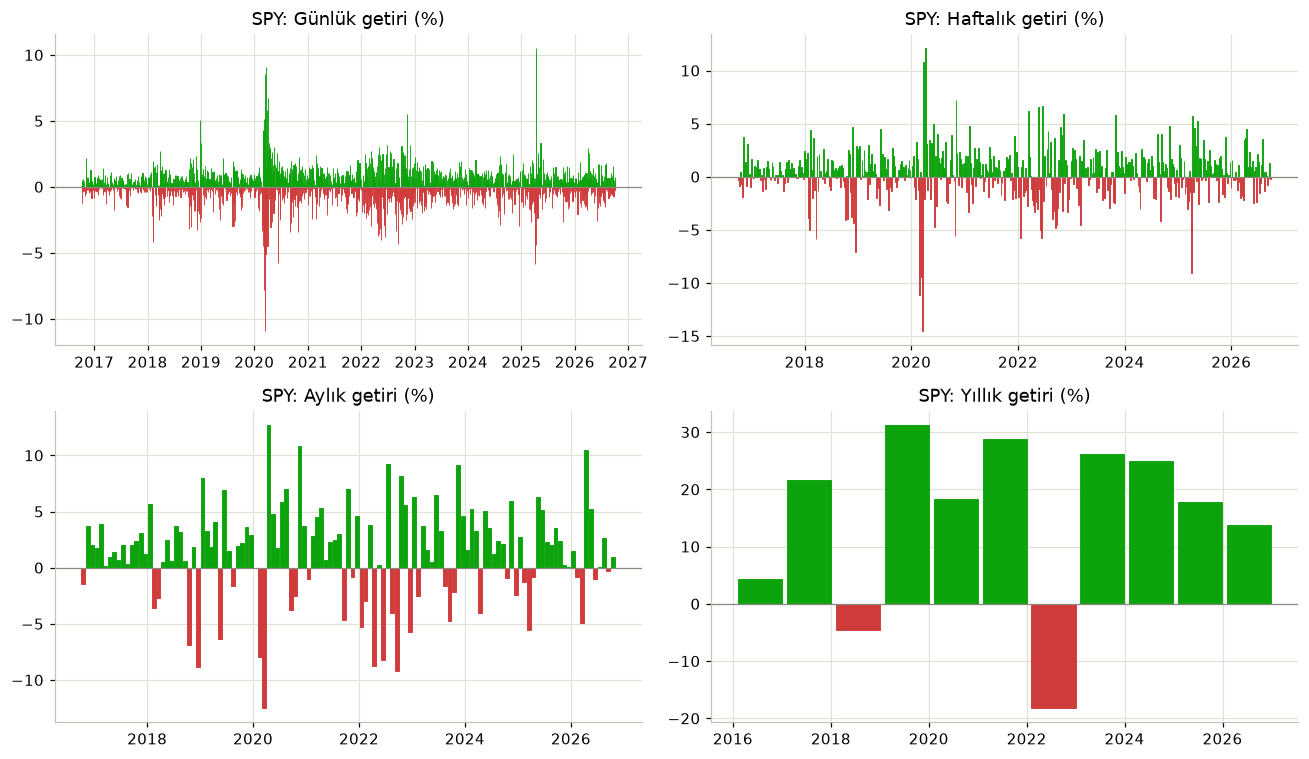

In [22]:
# Dört dönemi çubuk grafikle çiz: pozitif yeşil, negatif kırmızı.
# Her çubuk, dönemin başından sonuna kadar uzanır (genişlik gün cinsinden).
titles = {"daily": "Günlük", "weekly": "Haftalık", "monthly": "Aylık", "yearly": "Yıllık"}
days = {"daily": 1, "weekly": 7, "monthly": 30, "yearly": 365}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (name, (freq, date_format)) in zip(axes.flat, backtest.PERIODS.items()):
    returns = backtest.period_returns(price, freq)
    colors = [GREEN if value >= 0 else RED for value in returns]
    # edgecolor: günlük grafikteki çok ince çubuklar da görünsün diye
    ax.bar(returns.index, returns, width=-0.9 * days[name], align="edge",
           color=colors, edgecolor=colors, linewidth=0.6)
    ax.axhline(0, color="#898781", linewidth=0.8)
    ax.set_title(f"{symbol}: {titles[name]} getiri (%)")
fig.tight_layout()
plt.show()

Yıllık getirileri dört sembol için yan yana görelim. İlk yıl (veri yılın ortasında başladığı için) ve içinde bulunulan yıl **kısmi** yıllardır.

In [23]:
yearly = pd.DataFrame({
    s: backtest.period_returns(backtest.load_clean(s)["adj_close"], "YE") for s in config.SYMBOLS
})
yearly.index = yearly.index.year
yearly.index.name = "yıl"
yearly

,SPY,QQQ,GLD,TUR
yıl,,,,
2016,4.27,0.03,-9.25,-14.03
2017,21.71,32.66,12.81,37.58
2018,-4.57,-0.13,-1.94,-41.46
2019,31.22,38.96,17.86,14.49
2020,18.33,48.41,24.81,-1.19
2021,28.73,27.42,-4.15,-27.41
2022,-18.18,-32.58,-0.77,105.75
2023,26.18,54.86,12.69,-8.83
2024,24.89,25.58,26.66,12.91


## 5. Strateji: SMA kesişimi

**Kural:** 50 günlük ortalama (SMA50), 200 günlük ortalamanın (SMA200) üstündeyse pozisyonda ol; değilse nakitte bekle.

**Look-ahead bias:** Bir günün sinyali o günün kapanış fiyatıyla hesaplanır. Aynı günün getirisini bu sinyalle almak, henüz bilinmeyen bir bilgiyi kullanmak olurdu. Bu yüzden sinyal bir gün kaydırılır (`shift(1)`): bugünkü pozisyonu dünün sinyali belirler.

In [24]:
show_code(backtest.add_signals)

```python
def add_signals(df):
    """Fiyata hareketli ortalamaları, sinyali ve pozisyonu ekler."""
    # Fiyat olarak düzeltilmiş kapanışı kullanıyoruz (temettü ve bölünmeler dahil).
    data = pd.DataFrame({"price": df["adj_close"]})
    data["sma_short"] = data["price"].rolling(config.SMA_SHORT).mean()
    data["sma_long"] = data["price"].rolling(config.SMA_LONG).mean()

    # Sinyal: kısa ortalama uzun ortalamanın üstündeyse 1 (pozisyonda ol), değilse 0 (nakit).
    # İlk SMA_LONG - 1 günde uzun ortalama yoktur (NaN); karşılaştırma False verir, yani nakit.
    data["signal"] = (data["sma_short"] > data["sma_long"]).astype(int)

    # Look-ahead bias olmaması için sinyali 1 gün kaydırıyoruz: bugünkü pozisyonu
    # dünün kapanışında oluşan sinyal belirler, bugünün fiyatı karara girmez.
    data["position"] = data["signal"].shift(1).fillna(0).astype(int)
    return data

```

In [25]:
data = backtest.add_signals(backtest.load_clean(symbol))

# SMA200'ün ilk kez hesaplanabildiği günün çevresi: sinyal 1 olduktan bir gün sonra pozisyon 1 olur
first = config.SMA_LONG - 1
data.iloc[first - 2 : first + 3]

,price,sma_short,sma_long,signal,position
date,,,,,
2017-07-19,214.13,209.47,NaN,0,0
2017-07-20,214.23,209.62,NaN,0,0
2017-07-21,214.04,209.76,198.91,1,0
2017-07-24,213.99,209.91,199.06,1,1
2017-07-25,214.51,210.08,199.22,1,1


Sinyalin değiştiği günler alım-satım günleridir: işlem o günün kapanış fiyatıyla yapılır, pozisyon bir sonraki işlem gününde değişir. `list_trades` bu günleri listeler:

In [26]:
show_code(backtest.list_trades)

```python
def list_trades(data):
    """Al/sat işlemlerini listeler. İşlem, sinyalin değiştiği günün kapanış fiyatıyla yapılır."""
    data = data.iloc[:-1]  # son günün sinyali henüz işleme dönüşmedi (pozisyon ertesi gün değişir)
    changed = data[data["signal"].diff().abs() == 1]
    return [
        {
            "date": date.strftime("%Y-%m-%d"),
            "type": "AL" if row["signal"] == 1 else "SAT",
            "price": round(float(row["price"]), 2),
        }
        for date, row in changed.iterrows()
    ]

```

In [27]:
trades = pd.DataFrame(backtest.list_trades(data))
trades["date"] = pd.to_datetime(trades["date"])
print("İşlem sayısı:", len(trades))
trades

İşlem sayısı: 9


,date,type,price
0,2017-07-21,AL,214.04
1,2018-12-12,SAT,235.51
2,2019-03-26,AL,251.97
3,2020-03-31,SAT,235.74
4,2020-07-06,AL,291.25
5,2022-03-16,SAT,408.87
6,2023-01-26,AL,386.06
7,2025-04-16,SAT,517.08
8,2025-06-27,AL,606.66


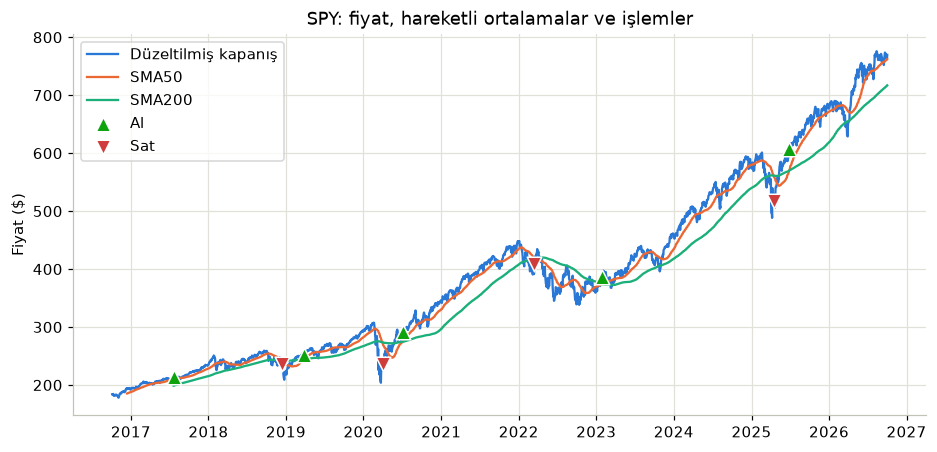

In [28]:
# Fiyat, iki ortalama ve al/sat işaretleri
buys = trades[trades["type"] == "AL"]
sells = trades[trades["type"] == "SAT"]

fig, ax = plt.subplots()
ax.plot(data.index, data["price"], color=BLUE, linewidth=1.5, label="Düzeltilmiş kapanış")
ax.plot(data.index, data["sma_short"], color=ORANGE, linewidth=1.5, label=f"SMA{config.SMA_SHORT}")
ax.plot(data.index, data["sma_long"], color=AQUA, linewidth=1.5, label=f"SMA{config.SMA_LONG}")
ax.scatter(buys["date"], buys["price"], marker="^", s=90, color=GREEN, edgecolor="white", zorder=3, label="Al")
ax.scatter(sells["date"], sells["price"], marker="v", s=90, color=RED, edgecolor="white", zorder=3, label="Sat")
ax.set_title(f"{symbol}: fiyat, hareketli ortalamalar ve işlemler")
ax.set_ylabel("Fiyat ($)")
ax.legend()
plt.show()

## 6. Backtest: portföy değeri ve metrikler

`equity_curve`, bir pozisyon serisi (1 = pozisyonda, 0 = nakit) için 10.000 $'lık portföyün değerini gün gün hesaplar. Her alım ve satımda %0,1 komisyon düşülür.

Buy & Hold da aynı fonksiyondan geçer: onun "sinyali" her gün 1'dir. Yani ilk günün kapanışında alınır, tek bir komisyon ödenir ve sona kadar tutulur.

In [29]:
show_code(backtest.equity_curve)

```python
def equity_curve(price, position):
    """Verilen pozisyon serisi (1 = pozisyonda, 0 = nakit) için portföy değerini hesaplar."""
    daily_return = price.pct_change().fillna(0)
    trade = position.diff().abs().fillna(0)  # yeni pozisyonun ilk günü 1, diğer günler 0
    # Pozisyondaysak günün getirisini alırız. İşlem bir önceki günün kapanışında
    # yapılmıştır; komisyonunu yeni pozisyonun ilk gününde düşeriz.
    growth = (1 + position * daily_return) * (1 - trade * config.COMMISSION)
    return config.INITIAL_CAPITAL * growth.cumprod()

```

In [30]:
# Strateji ve Buy & Hold için portföy değerleri
hold = pd.Series(1, index=data.index).shift(1).fillna(0)
equity = pd.DataFrame({
    "strategy": backtest.equity_curve(data["price"], data["position"]),
    "buy_hold": backtest.equity_curve(data["price"], hold),
})
display(equity.head(3), equity.tail(3))

,strategy,buy_hold
date,,
2016-10-05,"10,000.00","10,000.00"
2016-10-06,"10,000.00","9,996.95"
2016-10-07,"10,000.00","9,962.66"


,strategy,buy_hold
date,,
2026-09-30,"24,115.08","41,372.78"
2026-10-01,"24,158.09","41,446.56"
2026-10-02,"24,336.75","41,753.07"


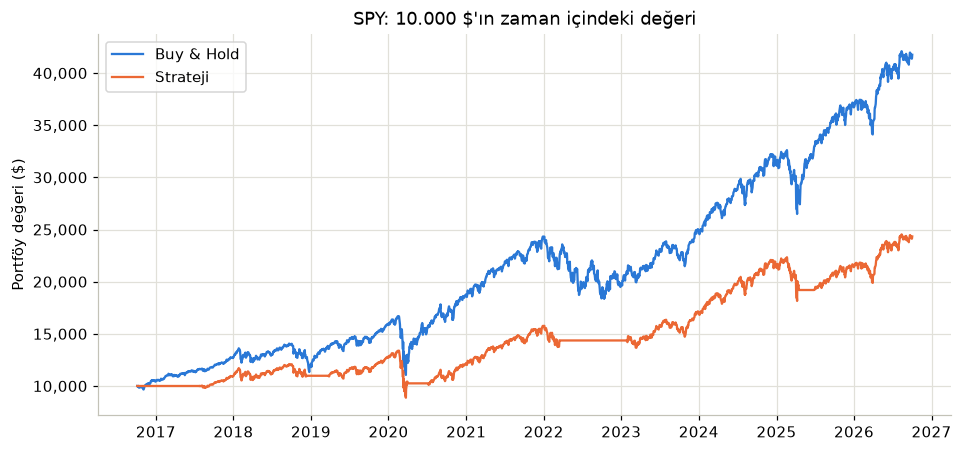

In [31]:
fig, ax = plt.subplots()
ax.plot(equity.index, equity["buy_hold"], color=BLUE, linewidth=1.5, label="Buy & Hold")
ax.plot(equity.index, equity["strategy"], color=ORANGE, linewidth=1.5, label="Strateji")
ax.set_title(f"{symbol}: 10.000 $'ın zaman içindeki değeri")
ax.set_ylabel("Portföy değeri ($)")
ax.yaxis.set_major_formatter("{x:,.0f}")  # eksende binlik ayırıcı
ax.legend()
plt.show()

Metrikler portföy değeri serisinden hesaplanır:

- **Toplam getiri:** son değer / başlangıç sermayesi − 1
- **CAGR:** yıllık bileşik getiri
- **Yıllık volatilite:** günlük getirilerin standart sapması × √252
- **Sharpe oranı:** yıllık ortalama getiri / yıllık volatilite (risksiz faiz 0)
- **Maksimum drawdown:** portföyün o güne kadarki zirvesinden en büyük düşüşü

In [32]:
show_code(backtest.compute_metrics)

```python
def compute_metrics(equity, trades):
    """Bir portföy değeri serisinden performans metriklerini hesaplar."""
    daily_return = equity.pct_change().dropna()
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    total_return = equity.iloc[-1] / config.INITIAL_CAPITAL - 1
    cagr = (1 + total_return) ** (1 / years) - 1  # yıllık bileşik getiri
    volatility = daily_return.std() * np.sqrt(config.TRADING_DAYS)
    # Sharpe oranı (risksiz faiz 0): yıllık ortalama getiri / yıllık oynaklık.
    # Portföy hiç pozisyona girmediyse oynaklık 0 olur; o durumda Sharpe 0 yazılır.
    sharpe = 0.0
    if volatility > 0:
        sharpe = daily_return.mean() * config.TRADING_DAYS / volatility
    drawdown = equity / equity.cummax() - 1  # o güne kadarki zirveye göre düşüş

    return {
        "final_value": round(float(equity.iloc[-1]), 2),
        "profit": round(float(equity.iloc[-1] - config.INITIAL_CAPITAL), 2),
        "total_return_pct": round(float(total_return * 100), 2),
        "cagr_pct": round(float(cagr * 100), 2),
        "volatility_pct": round(float(volatility * 100), 2),
        "sharpe": round(float(sharpe), 2),
        "max_drawdown_pct": round(float(drawdown.min() * 100), 2),
        "trades": trades,
    }

```

In [33]:
# Her satır bir portföy, her sütun bir metrik
metrics = pd.DataFrame(
    [
        backtest.compute_metrics(equity["strategy"], trades=len(trades)),
        backtest.compute_metrics(equity["buy_hold"], trades=1),
    ],
    index=["Strateji", "Buy & Hold"],
)
metrics

,final_value,profit,total_return_pct,cagr_pct,volatility_pct,sharpe,max_drawdown_pct,trades
Strateji,"24,336.75","14,336.75",143.37,9.31,15.10,0.67,-33.72,9
Buy & Hold,"41,753.07","31,753.07",317.53,15.38,17.95,0.89,-33.72,1


## 7. Tüm semboller

`analyze` fonksiyonu yukarıdaki adımların hepsini tek bir sembol için arka arkaya yapar ve dashboard'un okuyacağı iki sözlüğü döndürür: özet (metrikler) ve detay (günlük seriler, işlemler, getiriler).

In [34]:
show_code(backtest.analyze)

```python
def analyze(symbol):
    """Bir sembolün tüm hesaplarını yapar. (özet, detay) sözlüklerini döndürür."""
    data = add_signals(load_clean(symbol))
    price = data["price"]

    # Buy & Hold: sinyal her gün 1. Stratejiyle aynı kuraldan geçer, yani ilk günün
    # kapanışında alınır ve o tek işlem için komisyon ödenir.
    hold = pd.Series(1, index=price.index).shift(1).fillna(0)
    data["strategy"] = equity_curve(price, data["position"])
    data["buy_hold"] = equity_curve(price, hold)

    signals = list_trades(data)
    returns = {
        name: to_points(period_returns(price, freq), date_format)
        for name, (freq, date_format) in PERIODS.items()
    }

    detail = {
        "symbol": symbol,
        "daily": to_records(data[["price", "sma_short", "sma_long", "strategy", "buy_hold"]]),
        "signals": signals,
        "returns": returns,
        "strategy_yearly": to_points(period_returns(data["strategy"], "YE"), "%Y"),
    }
    summary = {
        "symbol": symbol,
        "name": config.SYMBOLS[symbol],
        "start": price.index[0].strftime("%Y-%m-%d"),
        "end": price.index[-1].strftime("%Y-%m-%d"),
        "rows": len(price),
        "strategy": compute_metrics(data["strategy"], trades=len(signals)),
        "buy_hold": compute_metrics(data["buy_hold"], trades=1),  # tek işlem: ilk alım
    }
    return summary, detail

```

In [35]:
# Her sembol için analizi çalıştır ve sonuçları sakla
results = {s: backtest.analyze(s) for s in config.SYMBOLS}

# Karşılaştırma tablosu: her sembolde strateji ve Buy & Hold
rows = []
for s, (summary, detail) in results.items():
    strategy, buy_hold = summary["strategy"], summary["buy_hold"]
    rows.append({
        "sembol": s,
        "strateji getirisi (%)": strategy["total_return_pct"],
        "B&H getirisi (%)": buy_hold["total_return_pct"],
        "strateji Sharpe": strategy["sharpe"],
        "B&H Sharpe": buy_hold["sharpe"],
        "strateji maks. düşüş (%)": strategy["max_drawdown_pct"],
        "B&H maks. düşüş (%)": buy_hold["max_drawdown_pct"],
        "işlem sayısı": strategy["trades"],
        "kazanan": "Strateji" if strategy["total_return_pct"] > buy_hold["total_return_pct"] else "Buy & Hold",
    })
comparison = pd.DataFrame(rows).set_index("sembol")
comparison

,strateji getirisi (%),B&H getirisi (%),strateji Sharpe,B&H Sharpe,strateji maks. düşüş (%),B&H maks. düşüş (%),işlem sayısı,kazanan
sembol,,,,,,,,
SPY,143.37,317.53,0.67,0.89,-33.72,-33.72,9,Buy & Hold
QQQ,377.52,574.57,0.91,0.96,-28.56,-35.12,9,Buy & Hold
GLD,135.44,214.42,0.67,0.78,-27.06,-26.40,14,Buy & Hold
TUR,-55.41,19.42,-0.23,0.22,-66.71,-59.25,18,Buy & Hold


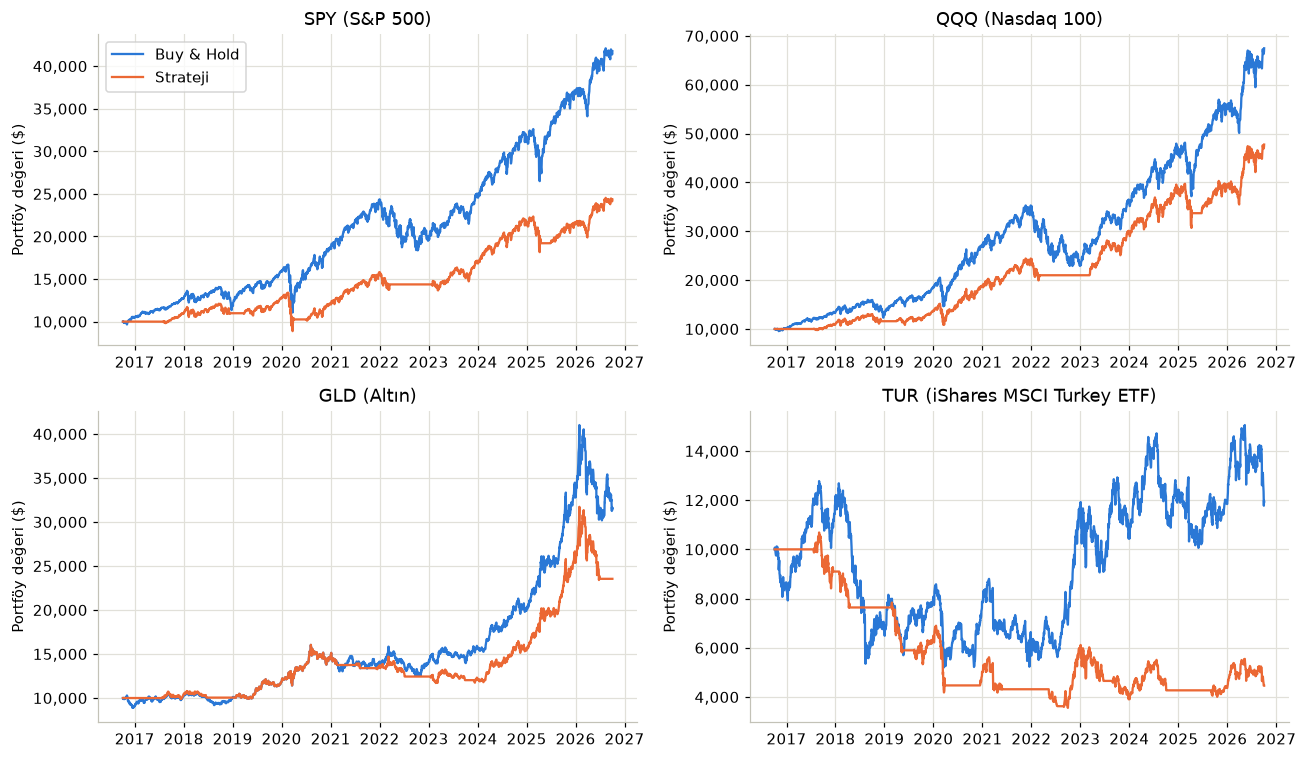

In [36]:
# Dört sembolün portföy değeri eğrileri
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (s, (summary, detail)) in zip(axes.flat, results.items()):
    daily = pd.DataFrame(detail["daily"])
    daily["date"] = pd.to_datetime(daily["date"])
    ax.plot(daily["date"], daily["buy_hold"], color=BLUE, linewidth=1.5, label="Buy & Hold")
    ax.plot(daily["date"], daily["strategy"], color=ORANGE, linewidth=1.5, label="Strateji")
    ax.set_title(f"{s} ({summary['name']})")
    ax.set_ylabel("Portföy değeri ($)")
    ax.yaxis.set_major_formatter("{x:,.0f}")
axes[0, 0].legend()
fig.tight_layout()
plt.show()

## 8. Mantık kontrolleri

Sonuçlara güvenmeden önce birkaç basit kontrol:

In [37]:
for s, (summary, detail) in results.items():
    first_day = detail["daily"][0]
    print(
        f"{s}: {summary['rows']} satır ({summary['start']} - {summary['end']}), "
        f"ilk gün portföy değeri: strateji {first_day['strategy']:,.0f} $, Buy & Hold {first_day['buy_hold']:,.0f} $"
    )

    # 1) Satır sayısı: 10 yıl x yaklaşık 252 işlem günü = 2500 civarı olmalı
    assert 2400 < summary["rows"] < 2600
    # 2) Portföy değeri ilk gün tam başlangıç sermayesine eşit olmalı
    assert first_day["strategy"] == first_day["buy_hold"] == config.INITIAL_CAPITAL

spy = results["SPY"][0]["buy_hold"]
print(f"\nSPY Buy & Hold: toplam getiri %{spy['total_return_pct']}, yıllık bileşik %{spy['cagr_pct']}")

SPY: 2512 satır (2016-10-05 - 2026-10-02), ilk gün portföy değeri: strateji 10,000 $, Buy & Hold 10,000 $
QQQ: 2512 satır (2016-10-05 - 2026-10-02), ilk gün portföy değeri: strateji 10,000 $, Buy & Hold 10,000 $
GLD: 2512 satır (2016-10-05 - 2026-10-02), ilk gün portföy değeri: strateji 10,000 $, Buy & Hold 10,000 $
TUR: 2512 satır (2016-10-05 - 2026-10-02), ilk gün portföy değeri: strateji 10,000 $, Buy & Hold 10,000 $

SPY Buy & Hold: toplam getiri %317.53, yıllık bileşik %15.38


**Look-ahead testi:** Strateji geleceği görmüyorsa, ileriki fiyatları değiştirmek geçmişteki pozisyonları değiştirmemelidir. Son 250 günün fiyatını %50 artırıp daha önceki pozisyonların aynı kaldığını kontrol edelim:

In [38]:
original = backtest.load_clean("SPY")
changed = original.copy()
changed.iloc[-250:, changed.columns.get_loc("adj_close")] *= 1.5  # son 250 günün fiyatını değiştir

before = backtest.add_signals(original)["position"].iloc[:-250]
after = backtest.add_signals(changed)["position"].iloc[:-250]
print("Önceki pozisyonlar aynı mı?", before.equals(after))

Önceki pozisyonlar aynı mı? True


## 9. Sonuçların yorumu

Bu yorum, notebook'un çalıştırıldığı tarihteki veriye (5 Ekim 2016 - 2 Ekim 2026) dayanır; veri güncellendikçe rakamlar değişir.

**Getiri:** Dört sembolün dördünde de Buy & Hold, SMA stratejisinden daha yüksek toplam getiri sağladı.

| Sembol | Strateji | Buy & Hold | Kazanan |
|---|---|---|---|
| SPY | %143 | %318 | Buy & Hold |
| QQQ | %378 | %575 | Buy & Hold |
| GLD | %135 | %214 | Buy & Hold |
| TUR | -%55 | %19 | Buy & Hold |

**Neden?**

- **Gecikme.** Hareketli ortalamalar fiyatı geriden takip eder: strateji düşüşten sonra satar, toparlanma başladıktan sonra geri alır. Örneğin SPY'da strateji 31 Mart 2020'de 235,74 $'dan sattı (dip 23 Mart'taydı) ve 6 Temmuz 2020'de 291,25 $'dan geri aldı; aradaki yaklaşık %24'lük yükselişi kaçırdı.
- **Dalgalı piyasa.** TUR'da fiyat sık sık yön değiştirdiği için strateji 18 işlem yaptı; 9 al-sat turunun 7'sinde aldığından daha düşük fiyata sattı. Buy & Hold %19 kazandırırken strateji %55 kaybettirdi.
- **İlk 200 gün.** SMA200 oluşana kadar strateji nakitte bekler. Bu sürede SPY yaklaşık %16 yükseldi; Buy & Hold bu getiriyi aldı, strateji alamadı.

**Risk:** Strateji zamanın bir kısmında nakitte olduğu için yıllık volatilitesi dört sembolde de daha düşük (örneğin SPY'da %15,1'e karşı %17,9). Buna rağmen getiri kaybı daha büyük olduğu için Sharpe oranı da dört sembolde Buy & Hold lehine. Maksimum drawdown yalnızca QQQ'da belirgin biçimde iyileşti (-%28,6'ya karşı -%35,1); SPY'da aynı kaldı, GLD ve TUR'da kötüleşti.

**Sonuç:** Bu dönemde ve bu parametrelerle (50/200 gün, %0,1 komisyon) basit bir SMA kesişim stratejisi al ve tut yaklaşımını geçemedi. Sonuç seçilen döneme, parametrelere ve varsayımlara bağlıdır; farklı bir dönemde tablo değişebilir.

## 10. Dashboard

Bu notebook hesapları adım adım gösterir. Aynı adımlar tek komutla da çalıştırılabilir:

```
python run_all.py
```

Bu komut veriyi indirir, temizler, backtest'i çalıştırır ve sonuçları `public/data/` klasörüne JSON olarak yazar. Web sayfası (dashboard) yalnızca bu JSON dosyalarını okur.

*Bu çalışma bir ders ödevidir; yatırım tavsiyesi değildir.*